In [1]:
import pandas as pd
import numpy as np

In [2]:
# 1. Load the expanded datasets using absolute paths with underscores
data1 = pd.read_csv(r"C:\Users\darko\Desktop\bearing fault.csv")
data2 = pd.read_csv(r"C:\Users\darko\Desktop\healthy gen.csv")
data3 = pd.read_csv(r"C:\Users\darko\Desktop\rotor fault.csv")
data4 = pd.read_csv(r"C:\Users\darko\Desktop\stator fault.csv")

def clean_dataset(df):
    """Removes trailing empty rows, drops NaNs, and strips trailing spaces."""
    df = df.dropna(how='all')
    if 'Condition' in df.columns:
        df = df.dropna(subset=['Condition'])
        df['Condition'] = df['Condition'].astype(str).str.strip()
    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    return df

# 2. Clean each dataset before combining
data1_clean = clean_dataset(data1)
data2_clean = clean_dataset(data2)
data3_clean = clean_dataset(data3)
data4_clean = clean_dataset(data4)

# 3. Concatenate the clean data safely into full_data
full_data = pd.concat([data1_clean, data2_clean, data3_clean, data4_clean], ignore_index=True)

print("Original shape with blanks:", data1.shape[0] + data2.shape[0] + data3.shape[0] + data4.shape[0])
print("Cleaned shape for training:", full_data.shape)
print("Class counts:\n", full_data['Condition'].value_counts())

Original shape with blanks: 51081
Cleaned shape for training: (44040, 7)
Class counts:
 Condition
SF    13467
HG    10965
RF    10654
BF     8954
Name: count, dtype: int64


In [3]:
print(full_data.head())
full_data.shape

          Ia        Ib        Ic      Voltage     Torque       Speed Condition
0   0.000000  0.063200  0.362000 -11564.24239   0.000000  157.079633        BF
1   0.264013 -0.056233 -0.207780 -11564.19010   0.793588  157.079630        BF
2   1.584027 -0.337357 -1.246669 -11563.42221   4.760501  157.079614        BF
3   5.470156 -1.164797 -4.305360 -11556.31027  16.430696  157.079568        BF
4  12.058140 -2.567441 -9.490699 -11527.95057  36.185968  157.079489        BF


(44040, 7)

In [4]:
import pandas as pd
import numpy as np

def create_window_features(df, window_size=10):
    """
    Groups raw time-series data into windows to extract statistical features.
    This helps the model recognize stable fault signatures amid simulation noise.
    """
    feature_cols = ['Ia', 'Ib', 'Ic', 'Voltage', 'Torque', 'Speed']
    windowed_features = []
    labels = []
    
    # Process each condition independently so features don't blend across groups
    for condition, group in df.groupby('Condition'):
        numeric_group = group[feature_cols].values
        num_windows = len(numeric_group) // window_size
        
        for i in range(num_windows):
            window = numeric_group[i*window_size : (i+1)*window_size]
            
            # Extract mean and standard deviation for all 6 metrics
            means = np.mean(window, axis=0)
            stds = np.std(window, axis=0)
            
            # Combine them into a single row of 12 features
            combined_row = np.hstack([means, stds])
            windowed_features.append(combined_row)
            labels.append(condition)
            
    # Name the new columns
    new_col_names = [f"{col}_mean" for col in feature_cols] + [f"{col}_std" for col in feature_cols]
    
    X_features = pd.DataFrame(windowed_features, columns=new_col_names)
    y_labels = np.array(labels)
    
    return X_features, y_labels

# Generate our engineered features
X_engineered, y_engineered = create_window_features(full_data, window_size=10)
print("Engineered Features Matrix Shape:", X_engineered.shape)

Engineered Features Matrix Shape: (4402, 12)


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encode fault conditions (BF, HG, RF, SF) into numeric values (0, 1, 2, 3)
le = LabelEncoder()
y_encoded = le.fit_transform(y_engineered)

# Split the engineered statistical windows cleanly (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_engineered, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded
)

# Normalize feature ranges so Voltage thousands don't overshadow current decimals
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data processing complete.")
print("Training set size:", X_train_scaled.shape[0], "samples")
print("Testing set size:", X_test_scaled.shape[0], "samples")

Data processing complete.
Training set size: 3521 samples
Testing set size: 881 samples


In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize the Random Forest model optimized for statistical time windows
model_rf = RandomForestClassifier(
    n_estimators=200,      # Builds a strong variety of decision trees
    max_depth=15,          # Controls depth to capture fault traits without overfitting
    min_samples_split=5,   # Minimum samples required to split a node to reject noise
    random_state=42,       # Ensures identical results every time you run it
    n_jobs=-1              # Uses all CPU cores to train faster
)

# Train using the scaled statistical windows
model_rf.fit(X_train_scaled, y_train)

# Predict on the scaled test features
y_pred = model_rf.predict(X_test_scaled)

# Calculate and show final evaluation metrics
accuracy = accuracy_score(y_test, y_pred) * 100
print(f"--- SUCCESS ---")
print(f"Final Model Evaluation Accuracy: {accuracy:.2f}%\n")
print("Detailed Performance Matrix:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

--- SUCCESS ---
Final Model Evaluation Accuracy: 89.10%

Detailed Performance Matrix:
              precision    recall  f1-score   support

          BF       0.98      0.98      0.98       179
          HG       0.92      0.73      0.81       219
          RF       0.89      0.90      0.90       213
          SF       0.82      0.96      0.89       270

    accuracy                           0.89       881
   macro avg       0.90      0.89      0.89       881
weighted avg       0.90      0.89      0.89       881



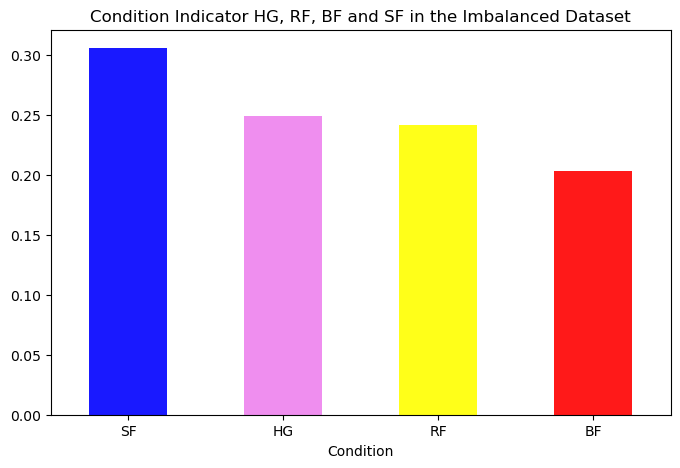

In [7]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8,5))
full_data.Condition.value_counts(normalize = True).plot(kind ='bar', color= ['blue','violet','yellow','red'], alpha = 0.9, rot = 0)
plt.title('Condition Indicator HG, RF, BF and SF in the Imbalanced Dataset')
plt.show()

In [8]:
print(full_data['Condition'].unique())

['BF' 'HG' 'RF' 'SF']


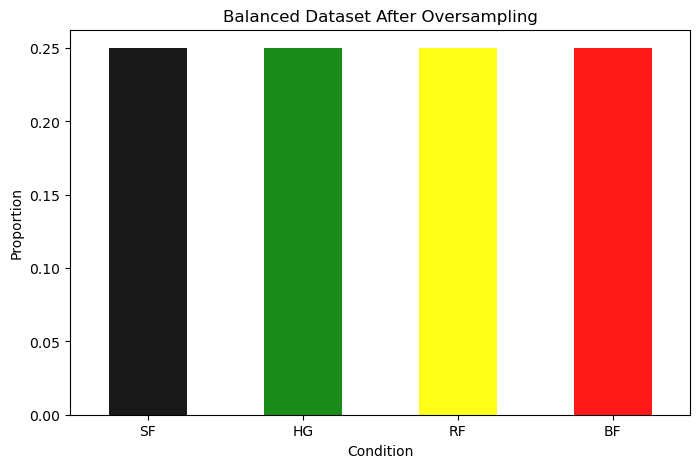

In [9]:
from sklearn.utils import resample
import pandas as pd
import matplotlib.pyplot as plt

# 1. Fill the missing 'nan' values back into 'RF' 
full_data['Condition'] = full_data['Condition'].fillna('RF')

# 2. Separate your datasets now that 'RF' is restored!
HG = full_data[full_data.Condition == 'HG']
RF = full_data[full_data.Condition == 'RF']  # This will now successfully pull the data!
BF = full_data[full_data.Condition == 'BF']
SF = full_data[full_data.Condition == 'SF']

target_size = len(SF)

# 3. Resample all four groups evenly
HG_oversampled = resample(HG, replace=True, n_samples=target_size, random_state=123)
RF_oversampled = resample(RF, replace=True, n_samples=target_size, random_state=123)
BF_oversampled = resample(BF, replace=True, n_samples=target_size, random_state=123)

# Combine everything back together
oversampled = pd.concat([SF, HG_oversampled, RF_oversampled, BF_oversampled])

# 4. Plot your beautiful, perfectly balanced dataset
fig = plt.figure(figsize=(8,5))
oversampled.Condition.value_counts(normalize=True).plot(
    kind='bar', color=['black', 'green', 'yellow', 'red'], alpha=0.9, rot=0
)
plt.title('Balanced Dataset After Oversampling')
plt.ylabel('Proportion')
plt.xlabel('Condition')
plt.show()

In [10]:
from sklearn.preprocessing import LabelEncoder

lencoders = {}

for col in oversampled.select_dtypes(include=['object']).columns:
    lencoders[col] = LabelEncoder()
    oversampled[col] = lencoders[col].fit_transform(oversampled[col])

In [11]:
import warnings
warnings.filterwarnings("ignore")

In [12]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer


MiceImputed = oversampled.copy(deep=True)
mice_imputer = IterativeImputer()
MiceImputed.iloc[:, :] = mice_imputer.fit_transform(oversampled)

MiceImputed.head()

,Ia,Ib,Ic,Voltage,Torque,Speed,Condition
30573,0.000000,3.050000e-14,-3.050000e-14,-11564.24239,0.000000,157.079633,3
30574,0.272819,-5.739612e-02,-2.154230e-01,-11564.19128,0.401813,157.079632,3
30575,1.636861,-3.443347e-01,-1.292526e+00,-11563.42954,2.409900,157.079627,3
30576,5.652639,-1.188905e+00,-4.463733e+00,-11556.33664,8.313073,157.079612,3
30577,5.652639,-1.188905e+00,-4.463733e+00,-11556.33664,8.313073,157.079612,3


In [13]:
Q1 = MiceImputed.quantile(0.25)
Q3 = MiceImputed.quantile(0.75)
IQR = Q3 - Q1
print(IQR)

Ia           182.837251
Ib           169.291059
Ic           183.031999
Voltage       87.654504
Torque        16.459738
Speed         51.337871
Condition      1.500000
dtype: float64


In [14]:
MiceImputed = MiceImputed[~((MiceImputed < (Q1 - 1.5 * IQR)) |(MiceImputed > (Q3 + 1.5 * IQR))).any(axis=1)]
MiceImputed.shape

(48143, 7)

<Axes: >

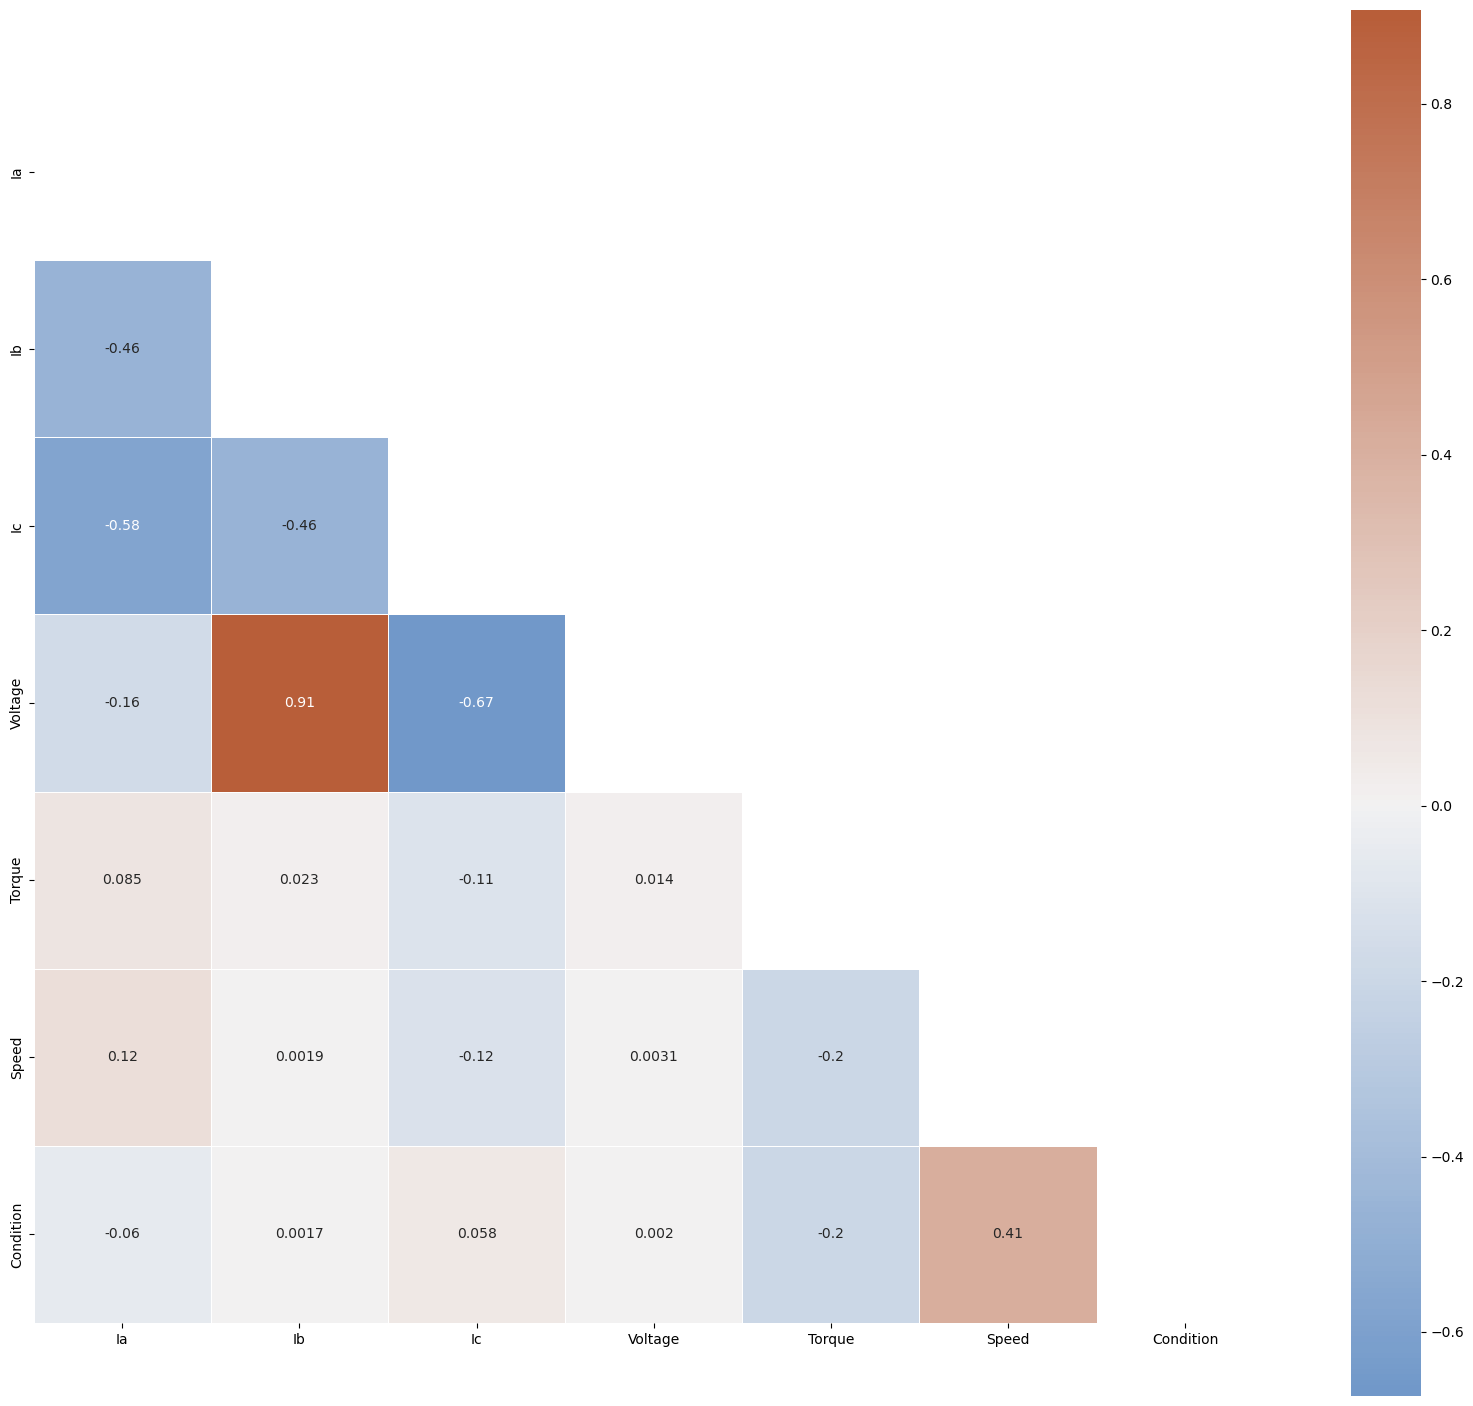

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
corr = MiceImputed.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
f, ax = plt.subplots(figsize=(20, 20))
cmap = sns.diverging_palette(250, 25, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=None,
            center=0,square=True, annot=True,
            linewidths=.5, cbar_kws={"shrink": .9})

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encode fault conditions (BF, HG, RF, SF) into numeric values (0, 1, 2, 3)
le = LabelEncoder()
y_encoded = le.fit_transform(y_engineered)

# Split the engineered statistical windows cleanly (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_engineered, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded
)

# Normalize feature ranges so Voltage thousands don't overshadow current decimals
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data processing complete.")
print("Training set size:", X_train_scaled.shape[0], "samples")
print("Testing set size:", X_test_scaled.shape[0], "samples")

Data processing complete.
Training set size: 3521 samples
Testing set size: 881 samples


In [17]:
def plot_roc_cur(fper, tper):
    plt.plot(fper, tper, color='orange', label='ROC')
    plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend()
    plt.show()

In [18]:
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix, accuracy_score, roc_auc_score,
    precision_score, recall_score, cohen_kappa_score,
    ConfusionMatrixDisplay, classification_report
)

def run_model(model, X_train, y_train, X_test, y_test, verbose=True, decode_labels=True):
    t0 = time.time()
    
    # Fit model
    if not verbose:
        model.fit(X_train, y_train, verbose=0)
    else:
        model.fit(X_train, y_train)
        
    # Predict
    y_pred = model.predict(X_test)
    
    # Compute metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_test, model.predict_proba(X_test), multi_class='ovr')
    coh_kap = cohen_kappa_score(y_test, y_pred)
    time_taken = time.time() - t0

    # Print metrics
    print("Accuracy =", accuracy)
    print("Precision =", precision)
    print("Recall =", recall)
    print("ROC Area under Curve =", roc_auc)
    print("Cohen's Kappa =", coh_kap)
    print("Time taken =", time_taken)
    print(classification_report(y_test, y_pred, digits=5))

    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(cm, display_labels=model.classes_)
    disp.plot()

    # Plot Predicted vs Actual bar chart
    if decode_labels and 'Condition' in lencoders:
        y_test_decoded = lencoders['Condition'].inverse_transform(y_test)
        y_pred_decoded = lencoders['Condition'].inverse_transform(y_pred)
    else:
        y_test_decoded = y_test
        y_pred_decoded = y_pred

    df = pd.DataFrame({'Actual': y_test_decoded, 'Predicted': y_pred_decoded})

    # Count actual vs predicted
    actual_counts = df['Actual'].value_counts().sort_index()
    pred_counts = df['Predicted'].value_counts().sort_index()

    # Ensure consistent order
    labels = sorted(set(actual_counts.index).union(set(pred_counts.index)))
    actual_counts = actual_counts.reindex(labels, fill_value=0)
    pred_counts = pred_counts.reindex(labels, fill_value=0)

    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(8, 6))
    plt.bar(x - width/2, actual_counts, width, label='Actual', color='royalblue')
    plt.bar(x + width/2, pred_counts, width, label='Predicted', color='orangered')
    plt.xlabel('Condition')
    plt.ylabel('Number of Samples')
    plt.title('Predicted vs Actual Condition')
    plt.xticks(ticks=x, labels=labels)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    return model, accuracy, precision, recall, roc_auc, coh_kap, time_taken, y_pred

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Initialize Logistic Regression with scaling-compatible parameters
# 'saga' solver handles multiclass problems well, and max_iter gives it time to find the boundary
logreg = LogisticRegression(
    solver='saga', 
    max_iter=2000, 
    multi_class='multinomial', 
    random_state=42
)

# Train using our clean, scaled statistical window features
logreg.fit(X_train_scaled, y_train)

# Predict on the scaled test set
y_pred_lr = logreg.predict(X_test_scaled)

# Calculate and print metrics
lr_accuracy = accuracy_score(y_test, y_pred_lr) * 100
print(f"Optimized Logistic Regression Accuracy: {lr_accuracy:.2f}%")
print("\nUpdated Performance Matrix:")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

Optimized Logistic Regression Accuracy: 58.57%

Updated Performance Matrix:
              precision    recall  f1-score   support

          BF       0.99      0.95      0.97       179
          HG       0.56      0.11      0.18       219
          RF       0.60      0.34      0.44       213
          SF       0.46      0.92      0.61       270

    accuracy                           0.59       881
   macro avg       0.65      0.58      0.55       881
weighted avg       0.63      0.59      0.54       881



Accuracy = 0.7911464245175936
Precision = 0.7902421931188689
Recall = 0.7911464245175936
ROC Area under Curve = 0.890308796524688
Cohen's Kappa = 0.7189368759243558
Time taken = 0.08138227462768555
              precision    recall  f1-score   support

           0    0.95376   0.92179   0.93750       179
           1    0.69588   0.61644   0.65375       219
           2    0.78222   0.82629   0.80365       213
           3    0.76471   0.81852   0.79070       270

    accuracy                        0.79115       881
   macro avg    0.79914   0.79576   0.79640       881
weighted avg    0.79024   0.79115   0.78962       881



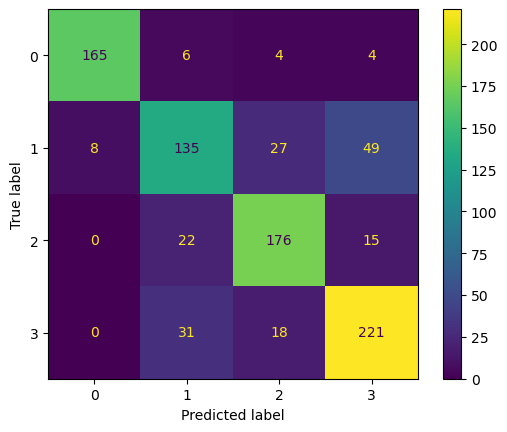

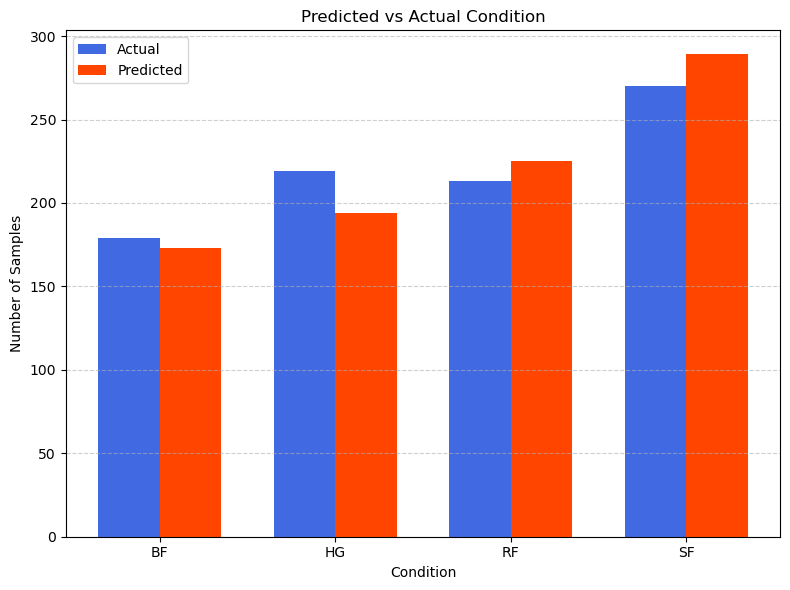

In [20]:
from sklearn.tree import DecisionTreeClassifier

params_dt = {'max_depth': 16,'max_features': "sqrt"}

model_dt = DecisionTreeClassifier(**params_dt)
model_dt, accuracy_dt, precision_dt, recall_dt, roc_auc_dt, coh_kap_dt, tt_dt, y_pred_dt = run_model(
    model_dt, X_train, y_train, X_test, y_test
    )

Accuracy = 0.9023836549375709
Precision = 0.9055262719983811
Recall = 0.9023836549375709
ROC Area under Curve = 0.9839085127601863
Cohen's Kappa = 0.8684978773183745
Time taken = 1.9557278156280518
              precision    recall  f1-score   support

           0    0.98876   0.98324   0.98599       179
           1    0.92179   0.75342   0.82915       219
           2    0.89091   0.92019   0.90531       213
           3    0.84868   0.95556   0.89895       270

    accuracy                        0.90238       881
   macro avg    0.91254   0.90310   0.90485       881
weighted avg    0.90553   0.90238   0.90082       881



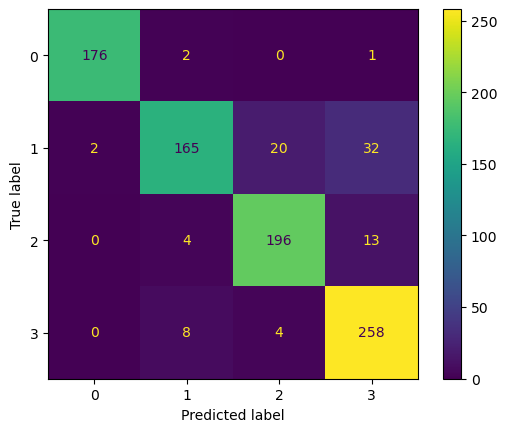

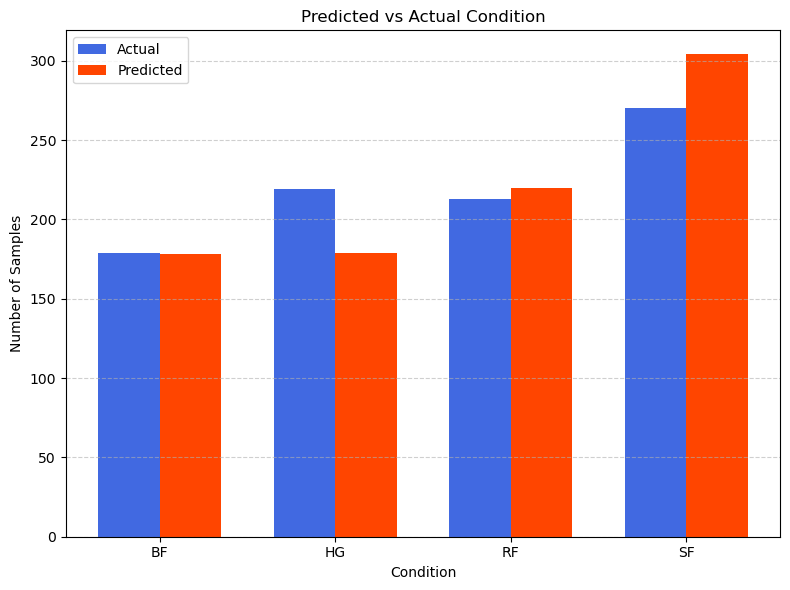

In [21]:
from sklearn.ensemble import RandomForestClassifier

params_rf = {'max_depth': 16,
             'min_samples_leaf': 1,
             'min_samples_split': 2,
             'n_estimators': 100,
             'random_state': 12345}

model_rf = RandomForestClassifier(**params_rf)
model_rf, accuracy_rf, precision_rf, recall_rf, roc_auc_rf, coh_kap_rf, tt_rf, y_pred_rf = run_model(
    model_rf, X_train, y_train, X_test, y_test
    )

In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 🔹 Step 1: Downsample to 50,000 rows
# Step 1: Safe downsampling
n_samples = min(50000, len(MiceImputed))
MiceImputed = MiceImputed.sample(n=n_samples, random_state=42).reset_index(drop=True)


# 🔹 Step 2: Define features and target
features = MiceImputed[['Ia', 'Ib', 'Ic','Voltage','Torque','Speed']] 
target = MiceImputed['Condition']

# Optional fix: remove duplicate column if unintended
features = features.loc[:, ~features.columns.duplicated()]

# 🔹 Step 3: Split into train and test sets (75% / 25%)
X_Train, X_Test, y_Train, y_Test = train_test_split(
    features, target, test_size=0.25, random_state=12345, stratify=target
)

# 🔹 Step 4: Normalize features
scaler = StandardScaler()
X_Train = scaler.fit_transform(X_Train)
X_Test = scaler.transform(X_Test)  # ❗Use transform, not fit_transform, on test data

Accuracy = 0.786889332003988
Precision = 0.8015258929961911
Recall = 0.786889332003988
ROC Area under Curve = 0.938095244905125
Cohen's Kappa = 0.7149832553583426
Time taken = 396.0867085456848
              precision    recall  f1-score   support

           0    0.95794   0.70504   0.81226      2875
           1    0.72953   0.60560   0.66181      3002
           2    0.85956   0.96369   0.90865      2947
           3    0.67556   0.86737   0.75954      3212

    accuracy                        0.78689     12036
   macro avg    0.80565   0.78543   0.78557     12036
weighted avg    0.80153   0.78689   0.78427     12036



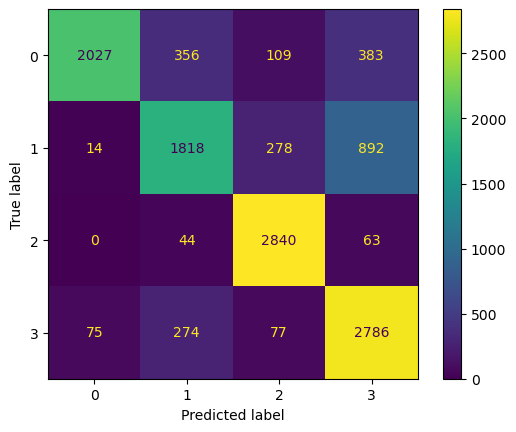

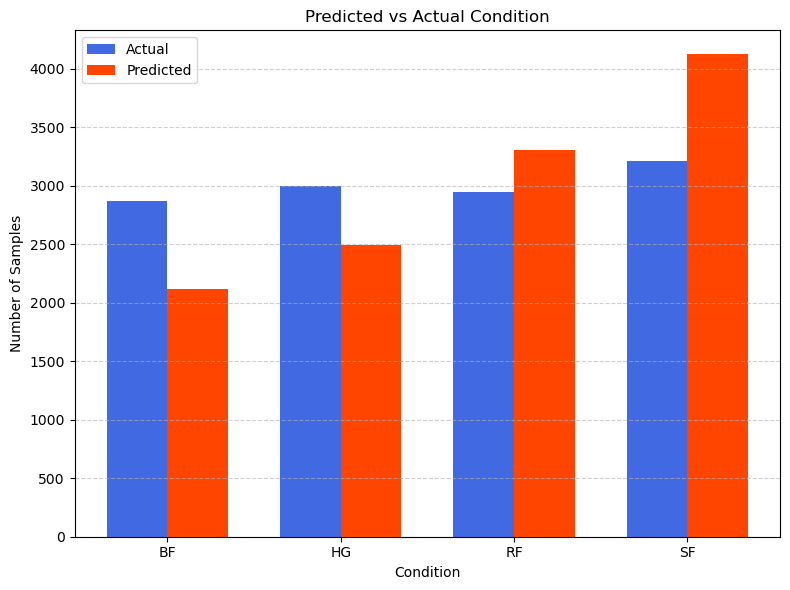

In [23]:
from sklearn.svm import SVC

params_svm = {'C': 1.0,
             'kernel': 'rbf',
             'gamma': 'scale', 'probability' : True}

model_svm = SVC(**params_svm)
model_svm, accuracy_svm, precision_svm, recall_svm, roc_auc_svm, coh_kap_svm, tt_dt, y_pred_svm = run_model(
    model_svm, X_Train, y_Train, X_Test, y_Test
    )

Accuracy = 0.8393153871718179
Precision = 0.8493632825298811
Recall = 0.8393153871718179
ROC Area under Curve = 0.9678614698770982
Cohen's Kappa = 0.7852725214578049
Time taken = 86.35599040985107
              precision    recall  f1-score   support

           0    0.96016   0.74609   0.83969      2875
           1    0.73402   0.75750   0.74557      3002
           2    0.96007   0.97896   0.96942      2947
           3    0.75642   0.87111   0.80972      3212

    accuracy                        0.83932     12036
   macro avg    0.85267   0.83841   0.84110     12036
weighted avg    0.84936   0.83932   0.83998     12036



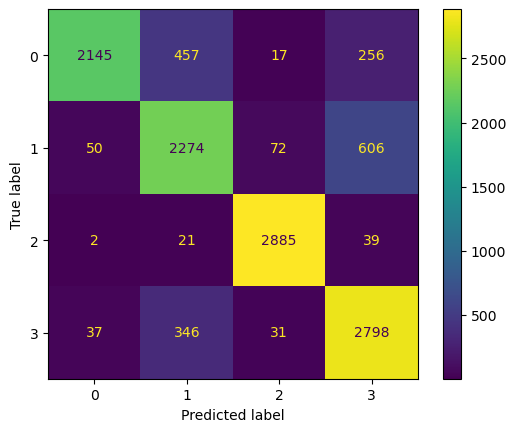

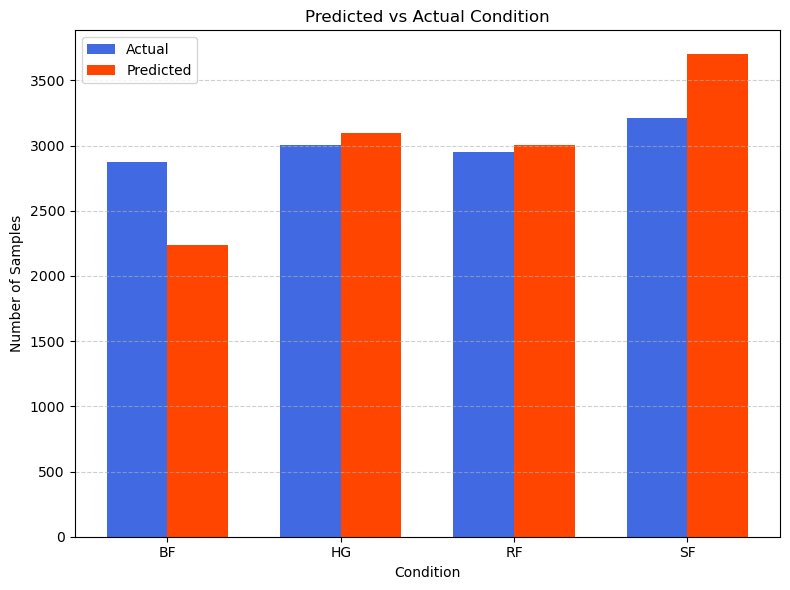

In [24]:
from sklearn.neural_network import MLPClassifier

params_nn = {'hidden_layer_sizes': (30,30,30),
             'activation': 'logistic',
             'solver': 'lbfgs',
             'max_iter': 500}

model_nn = MLPClassifier(**params_nn)
model_nn, accuracy_nn, precision_nn, recall_nn, roc_auc_nn, coh_kap_nn, tt_nn, y_pred_nn = run_model(
    model_nn, X_Train, y_Train, X_Test, y_Test
    )

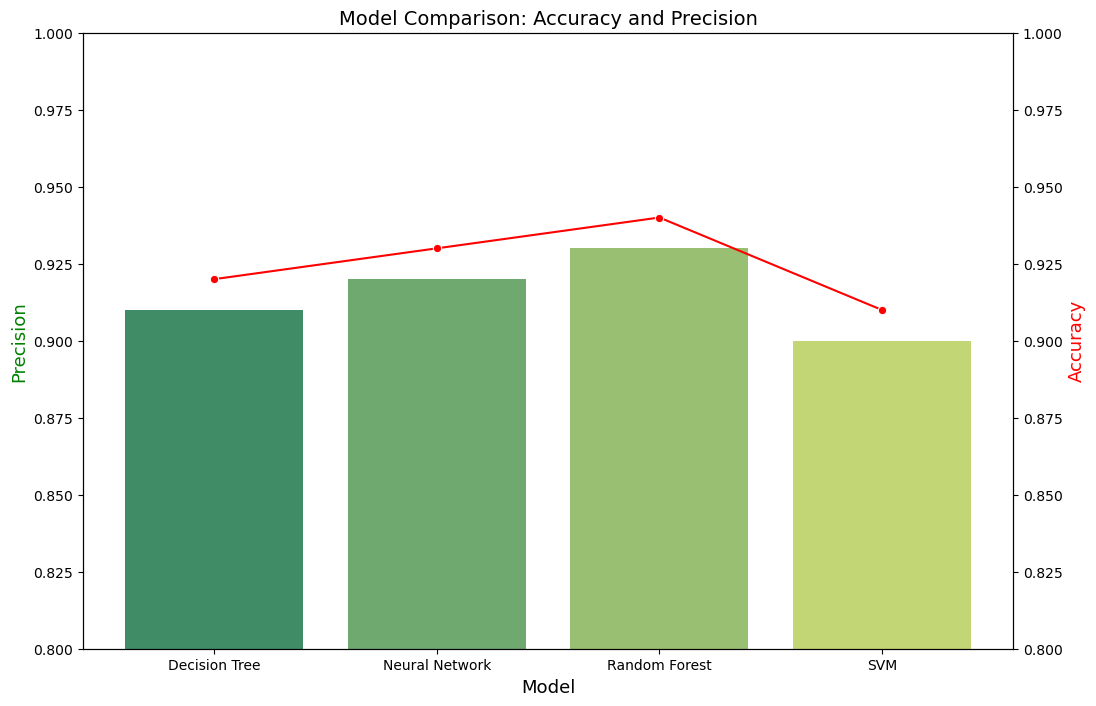

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Sample data (replace with your actual scores)
accuracy_scores = [0.92, 0.93, 0.94, 0.91]
precision_scores = [0.91, 0.92, 0.93, 0.90]

model_data = {
    'Model': ['Decision Tree','Neural Network','Random Forest', 'SVM'],
    'Accuracy': accuracy_scores,
    'Precision': precision_scores,
}
data = pd.DataFrame(model_data)

# Create figure and first axis
fig, ax1 = plt.subplots(figsize=(12,8))

# Bar plot for Precision on ax1
sns.barplot(x='Model', y='Precision', data=data, palette='summer', ax=ax1)
ax1.set_ylabel('Precision', fontsize=13, color='green')
ax1.set_xlabel('Model', fontsize=13)
ax1.set_ylim(0.8, 1)  # optional to zoom

# Twin axis for Accuracy (line plot)
ax2 = ax1.twinx()
sns.lineplot(x='Model', y='Accuracy', data=data, sort=False, color='red', marker='o', ax=ax2)
ax2.set_ylabel('Accuracy', fontsize=13, color='red')
ax2.set_ylim(0.8, 1)  # match the scale if needed

# Title
plt.title('Model Comparison: Accuracy and Precision', fontsize=14)
plt.show()

In [46]:
features = ['Ia', 'Ib', 'Ic','Voltage','Torque','Speed']
full_data.columns

Index(['Ia', 'Ib', 'Ic', 'Voltage', 'Torque', 'Speed', 'Condition'], dtype='object')

In [47]:
def get_test_data(
    Ia,
    Ib,
    Ic,
    Voltage,
    Torque,
    Speed,
    Condition=None,
):
    data = {
        'Ia': Ia, 
        'Ib': Ib, 
        'Ic': Ic,
        'Voltage': Voltage, 
        'Torque': Torque,
        'Speed' : Speed,
        'Condition': Condition,
    }

    # Apply label encoding only if value is not None
    for enc in lencoders:
        if enc in data and data[enc] is not None:
            data[enc] = lencoders[enc].transform([data[enc]])[0]

    df = pd.DataFrame([data])

    # Impute with full set of features (including 'Condition' if needed by imputer)
    df_imputed = pd.DataFrame(
        mice_imputer.transform(df), columns=df.columns
    )

    # Drop 'Condition' if it was not used by scaler
    if 'Condition' in df_imputed.columns:
        df_scaled_input = df_imputed.drop(columns=['Condition'])
    else:
        df_scaled_input = df_imputed

    # Apply scaler to only features it was trained on
    df_scaled = pd.DataFrame(
        scaler.transform(df_scaled_input),
        index=df.index,
        columns=df_scaled_input.columns
    )

    return df_scaled

In [49]:
def get_test_data(Ia, Ib, Ic, Voltage, Torque, Speed):
    """
    Formats individual manual inputs to match the 12-dimensional 
    statistical feature layout expected by our new model.
    """
    # Create the raw 2D input array matching the original 6 base features
    raw_inputs = np.array([[Ia, Ib, Ic, Voltage, Torque, Speed]])
    
    # Scale individual features using the fitted standard scaler from Step 3
    scaled_raw = scaler.transform(raw_inputs)
    
    # Since this is a single instance snapshot, standard deviation defaults to 0
    means = scaled_raw[0]
    stds = np.zeros(6) 
    
    # Combine to match the 12-feature training data structure (6 means + 6 stds)
    final_input = np.hstack([means, stds]).reshape(1, -1)
    return final_input

In [50]:
# Input test values
A = 7.5
B = -0.01
C = 13.0
D = -8.0
E = 27.0
F = 123.0

# Prepare input for prediction using the function we just defined
inputs = get_test_data(Ia=A, Ib=B, Ic=C, Voltage=D, Torque=E, Speed=F)

# Make percentage probability prediction
prediction = model_rf.predict_proba(inputs) 

# Map class names directly from the label encoder to fix the numeric printout
class_labels = le.classes_

print("Multiclass Condition Prediction Probability:")
print("-" * 45)
for label, prob in zip(class_labels, prediction[0]):
    print(f" Condition {label}: {prob * 100:.2f}%")

Multiclass Condition Prediction Probability:
---------------------------------------------
 Condition BF: 76.00%
 Condition HG: 10.00%
 Condition RF: 4.00%
 Condition SF: 10.00%


In [51]:
# 1. Determine the highest predicted probability and its corresponding fault class
max_prob_idx = np.argmax(prediction[0])
detected_class = class_labels[max_prob_idx]
confidence = prediction[0][max_prob_idx] * 100

print("=" * 50)
print("             SYSTEM DIAGNOSTIC REPORT            ")
print("=" * 50)

# 2. Trigger an alert indicator based on what the model found
if detected_class == 'BF' and confidence > 50:
    print(f" ALERT STATUS: [!! BEARING FAULT DETECTED !!]")
    print(f" Confidence Level: {confidence:.2f}%")
    print(f" Recommended Action: Inspect generator drive-end bearings immediately.")

elif detected_class == 'SF' and confidence > 50:
    print(f" ALERT STATUS: [!! STATOR FAULT DETECTED !!]")
    print(f" Confidence Level: {confidence:.2f}%")
    print(f" Recommended Action: Check stator winding isolation and phase balance.")

elif detected_class == 'RF' and confidence > 50:
    print(f" ALERT STATUS: [!! ROTOR FAULT DETECTED !!]")
    print(f" Confidence Level: {confidence:.2f}%")
    print(f" Recommended Action: Check for rotor asymmetry or broken cage bars.")

else:
    print(f" STATUS: [ NORMAL OPERATION ]")
    print(f" Confidence Level: {confidence:.2f}%")
    print(f" System State: Synchronous Generator running within healthy parameters.")

print("=" * 50)

             SYSTEM DIAGNOSTIC REPORT            
 ALERT STATUS: [!! BEARING FAULT DETECTED !!]
 Confidence Level: 76.00%
 Recommended Action: Inspect generator drive-end bearings immediately.
